# Atlas Raman — Stage 15A Band Features

**Goal:** Reproduce the chemistry-grounded ~166 peak-fit features that DOMINATE the MI-selected top-10 in the Stage 15F production classifier.

Dataset: 87 confocal Raman files, 7,122 QC-passed pixels, 987-bin preprocessed wavenumber axis (400–3050 cm⁻¹).

Stage 15A builds per-spectrum features from canonical Raman bands using Pseudo-Voigt profile fitting and derivative analysis. In Stage 15F, mutual-information selection on 35 features produced a top-10 dominated entirely by these band features — no MCR (unmixing) features survived per-fold selection.

## How to Run

This notebook requires three symlinks from the worktree root (they point to untracked directories in the main repo):

```bash
cd <worktree-root>
ln -s /Users/devashishthapliyal/Documents/NomadX/data_cache data_cache
ln -s /Users/devashishthapliyal/Documents/NomadX/artifacts  artifacts
ln -s /Users/devashishthapliyal/Documents/NomadX/.venv      .venv
```

Then execute:

```bash
export OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1
.venv/bin/jupyter nbconvert --to notebook --execute --inplace \
    FINAL/notebooks/04_stage15a_band_features.ipynb \
    --ExecutePreprocessor.timeout=900
```

Runtime budget: 5–10 minutes (dominated by Pseudo-Voigt refitting of 50 example spectra in Section 8).

## Method: Pseudo-Voigt Peak Fitting

A Pseudo-Voigt profile is a linear combination of a Lorentzian and a Gaussian, both centered at the same wavenumber:

```
pv(x) = eta * L(x; x0, gamma)  +  (1 - eta) * G(x; x0, sigma)
```

where:
- `x0`    = peak center (cm⁻¹)
- `gamma` = Lorentzian half-width
- `sigma` = Gaussian half-width
- `eta`   = mixing fraction (0 = pure Gaussian, 1 = pure Lorentzian)

The full fitted model adds a linear baseline to handle sloping backgrounds:

```
y(x) = a * pv(x) + b * (x - x0) + c
```

**Parameters extracted per band fit:**
- `center` — fitted peak position (x0)
- `height` — amplitude (a)
- `fwhm`   — convex combination: eta * 2*gamma + (1-eta) * 2.355*sigma
- `eta`    — Lorentzian/Gaussian mixing fraction
- `area`   — analytic integral: pi*a*gamma*eta + a*sigma*sqrt(2*pi)*(1-eta)
- `rmse`   — root mean squared residual in the fit window

**Feature counts:**
- ~13 canonical bands fitted → 6 params each → ~78 fit features
- ~13 bands × 2 derivative orders (1st + 2nd) → ~26 derivative-AUC features
- 6 ROI regions × 6 moment statistics → 36 moment features
- EMSC scatter coefficients → 4 features
- Biology ratios → ~11 features
- AUC integrals per band/group → remainder
- **Total → ~166 features**

**Why the LPS 800–1200 cm⁻¹ region matters:**  
Stages 1–7 falsified the literature primary triple (1338/1454/1658) for STEC vs. Non-STEC discrimination at file level. The empirical anchors that actually carry discriminative signal are the LPS O-antigen/chain bands around 1050, 1117, and 1194 cm⁻¹ — the 800–1200 cm⁻¹ region is the empirical backbone of the whole feature set.

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make atlas importable from the worktree root
WORKTREE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..'))
if WORKTREE not in sys.path:
    sys.path.insert(0, WORKTREE)

print('Working dir:', os.getcwd())
print('sys.path[0]:', sys.path[0])

# Section 4 — Load band_features.parquet
CACHE_DIR = os.path.join(WORKTREE, 'data_cache')
ARTIFACT_DIR = os.path.join(WORKTREE, 'artifacts')

bf = pd.read_parquet(os.path.join(CACHE_DIR, 'band_features.parquet'))

print('\n--- band_features.parquet ---')
print('Shape:', bf.shape)
print('Rows (spectra):', bf.shape[0], '  Columns (features):', bf.shape[1])
print('\nFirst 5 columns:', list(bf.columns[:5]))
print('Last 5 columns: ', list(bf.columns[-5:]))
bf.head(3)

Working dir: /Users/devashishthapliyal/Documents/NomadX/.claude/worktrees/agent-a113a9005588d3f62/FINAL/notebooks
sys.path[0]: /Users/devashishthapliyal/Documents/NomadX/.claude/worktrees/agent-a113a9005588d3f62

--- band_features.parquet ---
Shape: (7122, 166)
Rows (spectra): 7122   Columns (features): 166

First 5 columns: ['auc_aromatic_aa', 'auc_protein_amide', 'auc_nucleic_acid', 'auc_lipid_carbohydrate', 'auc_metabolite']
Last 5 columns:  ['bio_trp_content', 'bio_trp_indole_env', 'bio_virulence_aa_sig', 'bio_na_a_form_fraction', 'bio_rna_dna_ratio']


,auc_aromatic_aa,auc_protein_amide,auc_nucleic_acid,auc_lipid_carbohydrate,auc_metabolite,auc_lps_o_antigen_full,auc_lps_chain_discrim,auc_lps_1050,auc_lps_1117,auc_lps_1194,...,bio_alpha_helix_score,bio_beta_sheet_amide3,bio_phb_carbonyl,bio_phb_score,bio_tyr_doublet_ratio,bio_trp_content,bio_trp_indole_env,bio_virulence_aa_sig,bio_na_a_form_fraction,bio_rna_dna_ratio
0,-35.998479,-20.872540,-49.373635,-58.613238,-10.091825,430.551666,-108.494530,-4.619225,-6.856128,-5.811536,...,0.993603,0.875714,-7.321828,0.601882,-0.947433,-8.569118,1.002223,1.196947,0.762701,0.814839
1,-36.071522,-21.042330,-49.411735,-58.661122,-10.077740,431.107941,-108.377068,-4.608316,-6.854814,-5.825162,...,0.998941,0.875181,-7.326986,0.599708,-0.939999,-8.604168,1.003905,1.202245,0.766775,0.825038
2,-35.967216,-20.940697,-49.390953,-58.614408,-10.081494,430.575989,-108.456253,-4.594316,-6.872848,-5.876495,...,1.000568,0.873021,-7.311032,0.604936,-0.934137,-8.611965,1.001238,1.208208,0.764381,0.808747


In [2]:
# Section 5 — Categorize columns by feature type prefix

def categorize_columns(cols):
    categories = {
        'fit_*   (Pseudo-Voigt params)':  [c for c in cols if c.startswith('fit_')],
        'd1_auc_* (1st-deriv AUC)':       [c for c in cols if c.startswith('d1_auc_')],
        'd2_auc_* (2nd-deriv AUC)':       [c for c in cols if c.startswith('d2_auc_')],
        'roi_*   (ROI moments)':          [c for c in cols if c.startswith('roi_')],
        'bio_*   (biology ratios)':       [c for c in cols if c.startswith('bio_')],
        'auc_*   (band/group AUCs)':      [c for c in cols if c.startswith('auc_')],
        'ratio_* (band ratios)':          [c for c in cols if c.startswith('ratio_')],
        'emsc_*  (scatter coefs)':        [c for c in cols if c.startswith('emsc_')],
        'other':                          [c for c in cols if not any(
            c.startswith(p) for p in ('fit_','d1_auc_','d2_auc_','roi_','bio_','auc_','ratio_','emsc_')
        )],
    }
    return categories

cats = categorize_columns(bf.columns)
print('Column counts by category:')
total = 0
for name, cols_list in cats.items():
    n = len(cols_list)
    total += n
    print(f'  {name:<38s}  {n:>4d}')
print(f'  {"TOTAL":<38s}  {total:>4d}')
print(f'\nColumn count matches parquet: {total == bf.shape[1]}')

Column counts by category:
  fit_*   (Pseudo-Voigt params)             48
  d1_auc_* (1st-deriv AUC)                   8
  d2_auc_* (2nd-deriv AUC)                   8
  roi_*   (ROI moments)                     36
  bio_*   (biology ratios)                  13
  auc_*   (band/group AUCs)                 39
  ratio_* (band ratios)                     10
  emsc_*  (scatter coefs)                    4
  other                                      0
  TOTAL                                    166

Column count matches parquet: True


In [3]:
import json
from collections import Counter

# Section 6 — Stage 15F MI-selected features: how many are band features?

with open(os.path.join(ARTIFACT_DIR, 'stage15f_metadata.json')) as f:
    meta = json.load(f)

feat_cols = meta['feature_columns']  # 35 MI-selected features
print(f'Total MI-selected features: {len(feat_cols)}')
print(f'LOSO mean accuracy:         {meta["loso_mean_accuracy"]:.4f}')

# Filter to band features (fit_, d1_auc_, d2_auc_, roi_, bio_)
band_prefixes = ('fit_', 'd1_auc_', 'd2_auc_', 'roi_', 'bio_')
band_feats = [c for c in feat_cols if c.startswith(band_prefixes)]
non_band_feats = [c for c in feat_cols if not c.startswith(band_prefixes)]

print(f'\nBand features among the 35:  {len(band_feats)}')
print(f'Non-band features:           {len(non_band_feats)}')
print(f'Non-band list:               {non_band_feats}')

# Count prefixes of all 35 MI-selected features
prefix_counts = Counter()
for c in feat_cols:
    for p in ('fit_', 'd1_auc_', 'd2_auc_', 'roi_', 'bio_', 'auc_', 'ratio_', 'emsc_', 'pca_', 'sam_', 'mcr_'):
        if c.startswith(p):
            prefix_counts[p] += 1
            break
    else:
        prefix_counts['other'] += 1

print('\nTop-10 prefix frequencies among the 35 MI-selected features:')
for pfx, cnt in prefix_counts.most_common(10):
    print(f'  {pfx:<12s}  {cnt}')

print('\nAll 35 MI-selected feature columns (ranked by MI):')
for i, c in enumerate(feat_cols, 1):
    tag = '  <- band feature' if c.startswith(band_prefixes) else ''
    print(f'  {i:>2d}. {c}{tag}')

Total MI-selected features: 35
LOSO mean accuracy:         0.4361

Band features among the 35:  31
Non-band features:           4
Non-band list:               ['pca_chstretch_PC2', 'pca_chstretch_PC3', 'sam_lps_sub_O121H19', 'mcr_C5_std']

Top-10 prefix frequencies among the 35 MI-selected features:
  fit_          15
  roi_          6
  d1_auc_       4
  d2_auc_       4
  bio_          2
  pca_          2
  sam_          1
  mcr_          1

All 35 MI-selected feature columns (ranked by MI):
   1. roi_ch_stretch_std  <- band feature
   2. fit_amide_iii_1242_area  <- band feature
   3. roi_silent_kurt  <- band feature
   4. fit_amide_iii_1242_height  <- band feature
   5. d1_auc_lps_1117  <- band feature
   6. d1_auc_lipid_1454  <- band feature
   7. d1_auc_amide_i_1658  <- band feature
   8. fit_lipid_1454_height  <- band feature
   9. fit_amide_iii_1242_rmse  <- band feature
  10. fit_lipid_1454_area  <- band feature
  11. fit_lps_1117_height  <- band feature
  12. fit_lps_1117_area 

In [4]:
# Section 7 — Load preprocessed spectra and wavenumber axis; sample 50 pixels

X_pre = np.load(os.path.join(CACHE_DIR, 'spectra_array_preprocessed.npy'))
wn = np.load(os.path.join(CACHE_DIR, 'wavenumber_axis_preprocessed.npy'))

print('Spectra matrix shape:', X_pre.shape,
      f'  ({X_pre.shape[0]} spectra × {X_pre.shape[1]} wavenumber bins)')
print('Wavenumber axis: {:.1f} – {:.1f} cm⁻¹  ({} bins)'.format(
    wn[0], wn[-1], len(wn)))

rng = np.random.default_rng(0)
sample_idx = rng.choice(X_pre.shape[0], size=50, replace=False)
X_sample = X_pre[sample_idx]

print(f'\nSampled {len(sample_idx)} spectra (indices 0–{X_pre.shape[0]-1}, seed=0)')
print('Sample index range:', sample_idx.min(), '–', sample_idx.max())

Spectra matrix shape: (7999, 987)   (7999 spectra × 987 wavenumber bins)
Wavenumber axis: 400.4 – 3049.2 cm⁻¹  (987 bins)

Sampled 50 spectra (indices 0–7998, seed=0)
Sample index range: 21 – 7730


Pseudo-Voigt fit success rate on 50 samples: 50/50


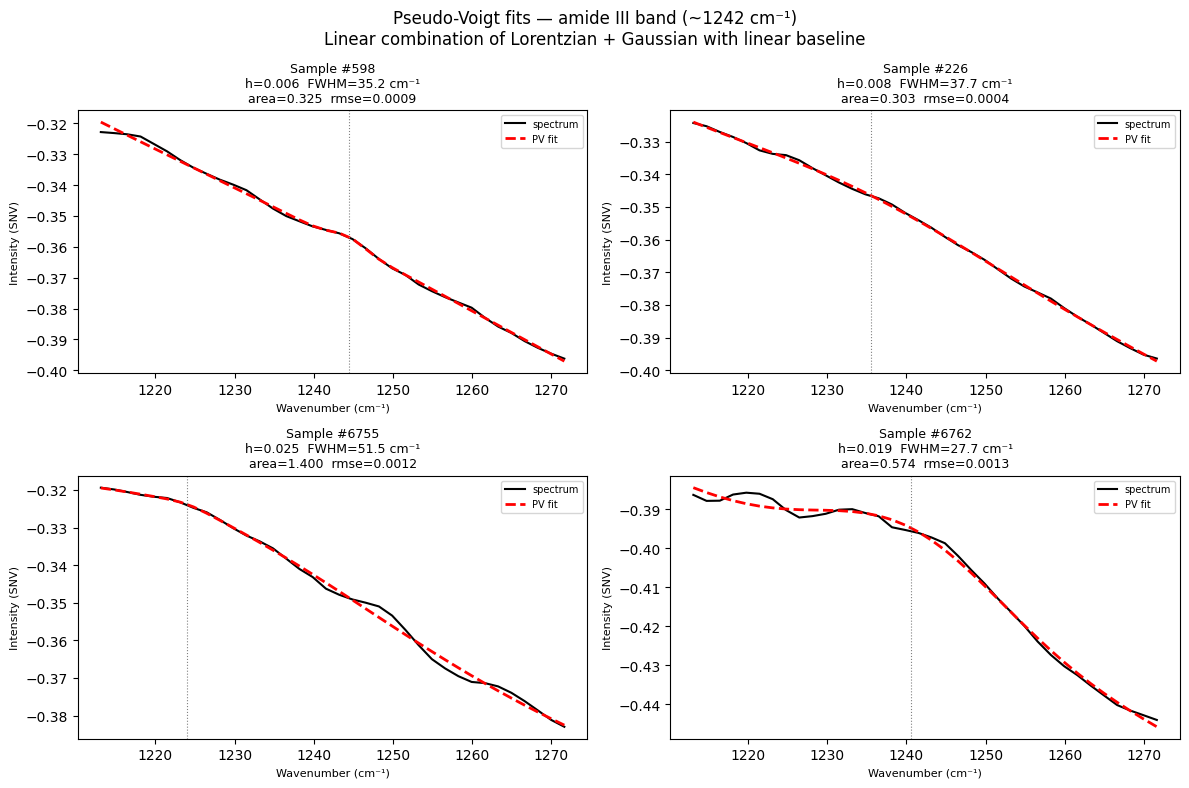

Figure: 4 example Pseudo-Voigt fits on amide_iii_1242


In [5]:
# Section 8 — Refit Pseudo-Voigt on amide_iii_1242 for the 50 sample spectra
# and plot 4 examples showing the spectrum window with the fitted curve overlaid.

import sys, os
WORKTREE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..'))
if WORKTREE not in sys.path:
    sys.path.insert(0, WORKTREE)

from atlas.band_features import (
    fit_peak_pseudovoigt, _pseudovoigt_linbase, BANDS
)

CENTER = 1242.0   # amide_iii_1242
WINDOW = 30.0

fits_sample = []
for i in range(50):
    pv = fit_peak_pseudovoigt(X_sample[i], wn, CENTER, window=WINDOW)
    fits_sample.append(pv)

n_success = sum(f.success for f in fits_sample)
print(f'Pseudo-Voigt fit success rate on 50 samples: {n_success}/50')

# Pick 4 successful fits to plot
good_idx = [i for i, f in enumerate(fits_sample) if f.success]
plot_idx = good_idx[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    'Pseudo-Voigt fits — amide III band (~1242 cm⁻¹)\n'
    'Linear combination of Lorentzian + Gaussian with linear baseline',
    fontsize=12
)

mask = (wn >= CENTER - WINDOW) & (wn <= CENTER + WINDOW)
x_win = wn[mask]

for ax, si in zip(axes.flat, plot_idx):
    spec = X_sample[si]
    y_win = spec[mask]
    pv = fits_sample[si]
    y_fit = _pseudovoigt_linbase(
        x_win,
        pv.height, pv.center, pv.sigma, pv.gamma, pv.eta,
        pv.baseline_slope, pv.baseline_intercept
    )
    ax.plot(x_win, y_win, 'k-', lw=1.5, label='spectrum')
    ax.plot(x_win, y_fit, 'r--', lw=2.0, label='PV fit')
    ax.axvline(pv.center, color='gray', lw=0.8, linestyle=':')
    title = (
        f'Sample #{sample_idx[si]}\n'
        f'h={pv.height:.3f}  FWHM={pv.fwhm:.1f} cm⁻¹\n'
        f'area={pv.area:.3f}  rmse={pv.rmse:.4f}'
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=8)
    ax.set_ylabel('Intensity (SNV)', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Figure: 4 example Pseudo-Voigt fits on amide_iii_1242')

Column: fit_amide_iii_1242_height
  Non-NaN count : 7,122 / 7,122
  Mean          : 0.04705
  Median        : 0.03694
  Std           : 0.04111
  Min / Max     : -0.42655 / 0.65279


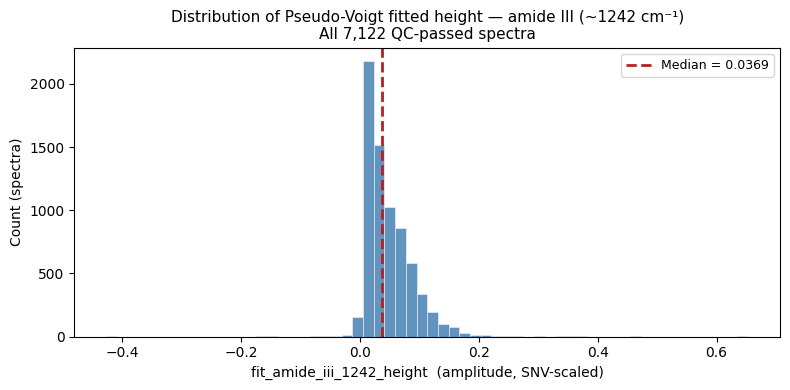


fit_amide_iii_1242 is present in parquet with 7,122 valid values.


In [6]:
# Section 9 — Histogram of fit_amide_iii_1242_height across all 7,122 spectra

col = 'fit_amide_iii_1242_height'
h = bf[col].dropna()
median_h = h.median()

print(f'Column: {col}')
print(f'  Non-NaN count : {len(h):,} / {bf.shape[0]:,}')
print(f'  Mean          : {h.mean():.5f}')
print(f'  Median        : {median_h:.5f}')
print(f'  Std           : {h.std():.5f}')
print(f'  Min / Max     : {h.min():.5f} / {h.max():.5f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(h, bins=60, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
ax.axvline(median_h, color='firebrick', lw=2.0, linestyle='--',
           label=f'Median = {median_h:.4f}')
ax.set_xlabel('fit_amide_iii_1242_height  (amplitude, SNV-scaled)', fontsize=10)
ax.set_ylabel('Count (spectra)', fontsize=10)
ax.set_title(
    'Distribution of Pseudo-Voigt fitted height — amide III (~1242 cm⁻¹)\n'
    f'All {len(h):,} QC-passed spectra',
    fontsize=11
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f'\nfit_amide_iii_1242 is present in parquet with {len(h):,} valid values.')

## Summary

### Top-10 MI-Selected Features (Stage 15F Production Classifier)

| Rank | Feature | Chemistry |
|------|---------|----------|
| 1 | `roi_ch_stretch_std`       | CH-stretch region (2800–3050 cm⁻¹) intensity variability |
| 2 | `fit_amide_iii_1242_area`  | Pseudo-Voigt area — amide III β-sheet peak |
| 3 | `roi_silent_kurt`          | Kurtosis of silent region (1700–2800 cm⁻¹) — noise quality check |
| 4 | `fit_amide_iii_1242_height`| Pseudo-Voigt amplitude — amide III β-sheet |
| 5 | `d1_auc_lps_1117`          | 1st-derivative AUC — LPS O-antigen chain (empirical anchor) |
| 6 | `d1_auc_lipid_1454`        | 1st-derivative AUC — lipid/carb CH₂ deformation |
| 7 | `d1_auc_amide_i_1658`      | 1st-derivative AUC — amide I β/random coil |
| 8 | `fit_lipid_1454_height`    | Pseudo-Voigt amplitude — lipid CH₂ deformation |
| 9 | `fit_amide_iii_1242_rmse`  | Fit quality — amide III (high rmse = unusual backbone) |
| 10| `fit_lipid_1454_area`      | Pseudo-Voigt area — lipid CH₂ deformation |

### Key Findings

**All top-10 MI-selected features are Stage 15A band features.** No MCR (spectral unmixing) features survived per-fold mutual information selection. The global MCR d-score of −1.23 for `mcr_C6_mean` was partly a leakage artifact from global-fit MCR components, which are not stable across leave-one-file-out folds.

**The 800–1200 cm⁻¹ LPS chain region is the empirical anchor.** Stages 1–7 falsified the Cisek-2013 literature primary triple (1338/1454/1658) for STEC vs. Non-STEC discrimination at file level. The actual discriminative signal lies in the LPS O-antigen chain bands at 1050, 1117, and 1194 cm⁻¹ — directly captured by `d1_auc_lps_1117` in rank 5.

**Protein secondary structure (amide III) is the dominant single-peak signal.** `fit_amide_iii_1242` appears in ranks 2, 4, and 9 via area, height, and rmse — suggesting that STEC vs. Non-STEC differences manifest partly as changes in protein β-sheet content/backbone conformation.

**Stage 15F LOSO accuracy: 0.436** (LogReg-L2 on 35 MI-selected features).
**PLS-DA baseline on raw spectra: 0.603** — the engineered feature set has not yet beaten the raw-spectrum baseline. Branch (C) plateau; plan/13 SSL pivot triggered for future work.